# Customer Churn Prediction Using Machine Learning

## Objective

Customer churn refers to customers discontinuing a company's service. Customer retention is generally more cost-effective than acquiring new customers. Therefore, predicting potential churners can help businesses take proactive measures to retain valuable customers.

## Problem Statement

Given customer demographic information, service details, contract information, and billing history, build machine learning models that can predict whether a customer is likely to churn.

## Dataset

IBM Telco Customer Churn Dataset

Number of Records: 7043
Number of Features: 21

Target Variable:
Churn
- Yes : Customer left the service
- No  : Customer stayed with the service

## Project Workflow

Phase 1 : Understanding the Dataset
- Understand the available features and target variable.

Phase 2 : Exploratory Data Analysis (EDA)
- Identify patterns and relationships between customer attributes and churn.

Phase 3 : Data Preprocessing
- Clean the dataset and convert categorical features into machine-readable format.

Phase 4 : Logistic Regression
- Train and evaluate a baseline classification model.

Phase 5 : Random Forest
- Train and evaluate an ensemble-based classification model.

Phase 6 : XGBoost
- Train and evaluate a gradient boosting model.

Phase 7 : Model Comparison
- Compare all models and select the best-performing model.

## PHASE 1 (Understanding the given dataset)

In [1]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()
#df.shape

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## PHASE 2(EDA)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset.csv")

Churn Distribution

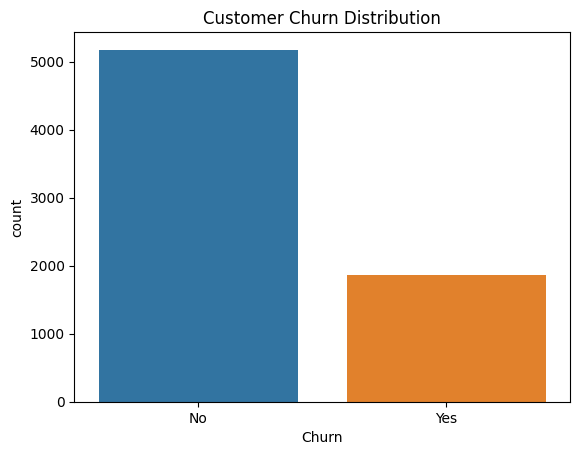

In [9]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

Tenure vs Churn

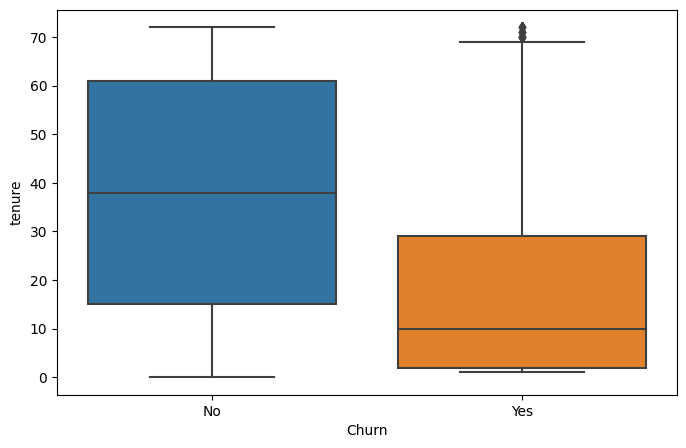

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

The customers who wants to leave the company have (churn = 'YES') have relatively low tenure than who are staying the company

Contract Type vs Churn

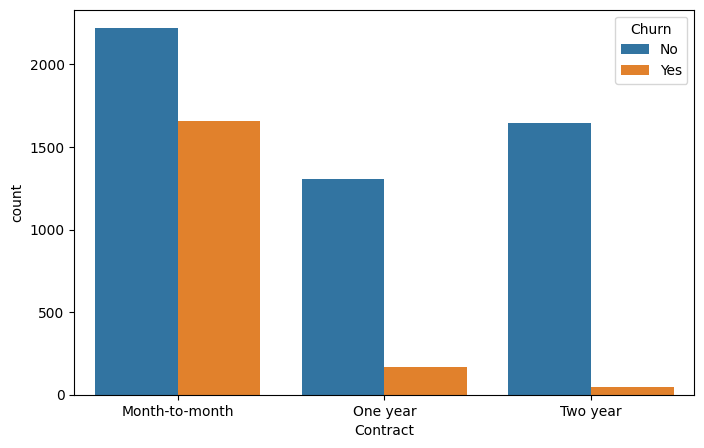

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

Customers with month-to-month contracts exhibit higher churn compared to customers with one-year and two-year contracts.

Monthly Charges vs Churn

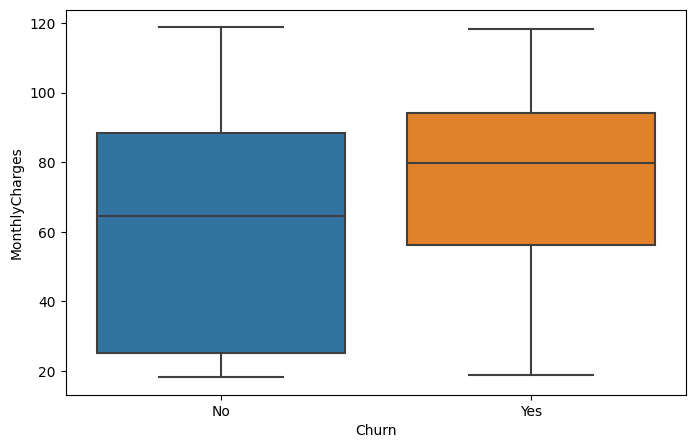

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

The people who are leaving the company are  paying higher range of charges than people who are staying

Internet Service vs Churn

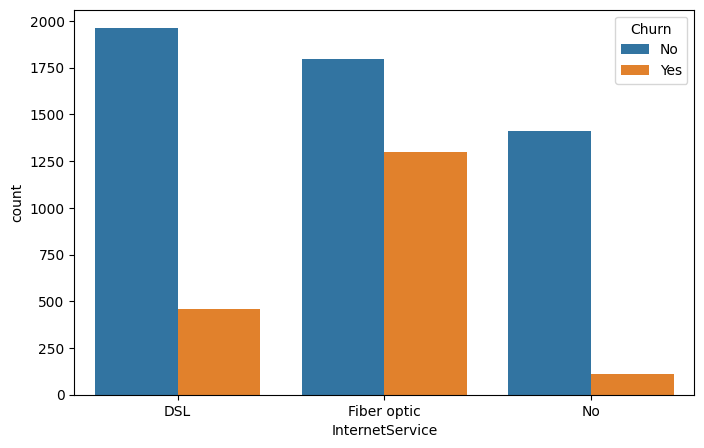

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

Fiber optic customers exhibit a higher churn count compared to DSL and customers without internet service.

Payment Method vs Churn

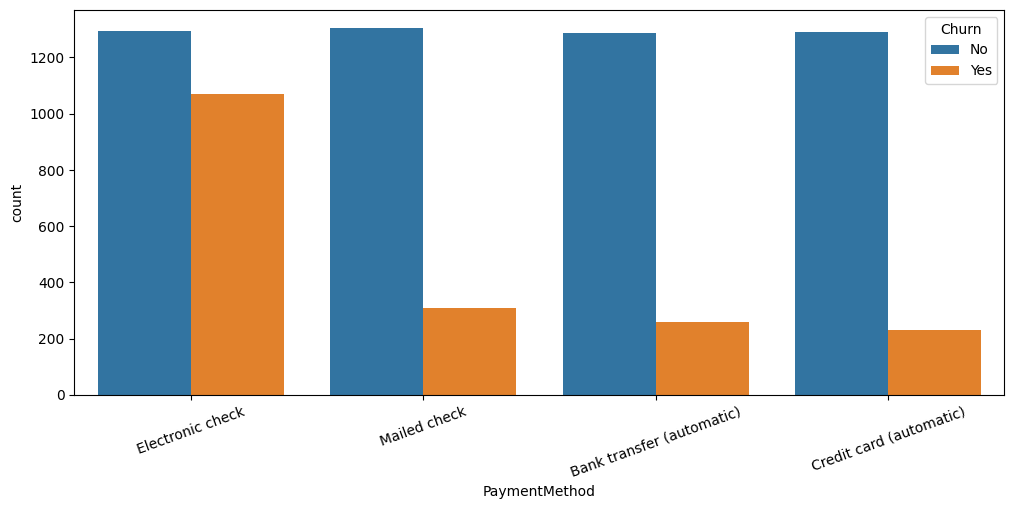

In [14]:
plt.figure(figsize=(12,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.show()

Customers using electronic check as their payment method show higher churn compared to other payment methods.

Correlation Heatmap

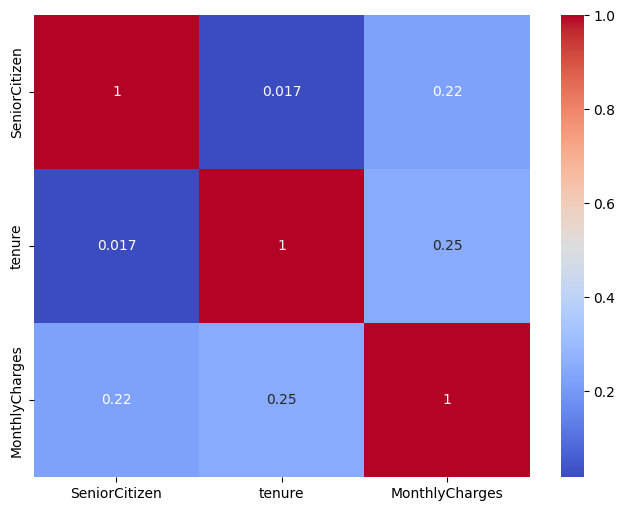

In [15]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

No strong linear correlation was observed among the numerical variables.

## PHASE-3(Data Preprocessing)

In [16]:
df_ml = df.copy()

Finding TotalCharges Datatype

In [17]:
df_ml["TotalCharges"].dtype

dtype('O')

In [18]:
df_ml["TotalCharges"] = pd.to_numeric(
    df_ml["TotalCharges"],
    errors="coerce"
)
df_ml["TotalCharges"].dtype

dtype('float64')

TotalCharges was stored as an object datatype and was converted to numeric format.

Ensure that there are no missing values present

In [19]:
df_ml.isnull().sum()
df_ml["TotalCharges"].fillna(
    df_ml["TotalCharges"].median(),
    inplace=True
)
df_ml.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values in TotalCharges were replaced using the median value.

Removing Customer ID

In [20]:
df_ml.drop("customerID", axis=1, inplace=True)
df_ml.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Customer id is like a Primary Key , it's obvious to remove that because it dosen't help us to draw paterns and contribute in churn prediction

Converting Target Variable

In [21]:
df_ml["Churn"] = df_ml["Churn"].map({
    "Yes": 1,
    "No": 0
})
df_ml["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

The target variable was converted into numerical form for machine learning.

Encoding  Categorical Features

In [22]:
df_ml.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [23]:
df_ml = pd.get_dummies(
    df_ml,
    drop_first=True
)
df_ml.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Categorical variables were transformed into numerical features using one-hot encoding.

Verifying Dataset

In [24]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

all of the temporary dataset has been converted into non object data type

Separate Features and Target

In [25]:
X = df_ml.drop("Churn", axis=1)

y = df_ml["Churn"]
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


### Splitting the Dataset

The dataset is divided into training and testing subsets using an 80-20 ratio.

Training Set:
Used to train the machine learning models.

Testing Set:
Used to evaluate the performance of trained models on unseen data.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


All categorical variables were encoded into numerical format, and the dataset now contains only numeric and boolean features suitable for machine learning.

## Model Evaluation Metrics

The following metrics are used:

Accuracy:
Measures overall prediction correctness.

Precision:
Measures how many predicted churners actually churned.

Recall:
Measures how many actual churners were successfully identified.

F1-Score:
Harmonic mean of precision and recall.

Confusion Matrix:
Provides detailed insight into classification performance.

## PHASE 4(Training the Logistic Regresssion model)

Training the model

In [60]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=3000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


The Logistic Regression model was trained on the training dataset.

Making predictions

In [28]:
y_pred = lr.predict(X_test)

Caluclating Accuaracy

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8218594748048261


The model has achieved ~82% Accuracy

Confusion Matrix

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[934 102]
 [149 224]]


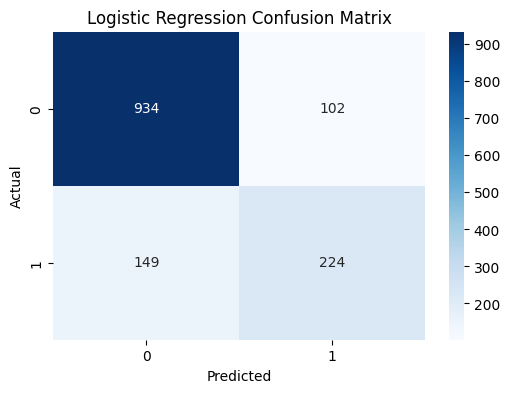

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



## PHASE 5(Training the Random Forest model)

Training Model

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


A Random Forest classifier was trained using 100 decision trees.

Predictions

In [35]:
rf_pred = rf.predict(X_test)

Accuaracy

In [36]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7892122072391767


Classification Report

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



Confusion Matrix

In [38]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[941  95]
 [202 171]]


In [39]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                           Feature  Importance
3                     TotalCharges    0.189701
1                           tenure    0.175710
2                   MonthlyCharges    0.172418
10     InternetService_Fiber optic    0.036053
28  PaymentMethod_Electronic check    0.035302
25               Contract_Two year    0.030435
13              OnlineSecurity_Yes    0.029238
4                      gender_Male    0.027423
26            PaperlessBilling_Yes    0.025295
5                      Partner_Yes    0.024209


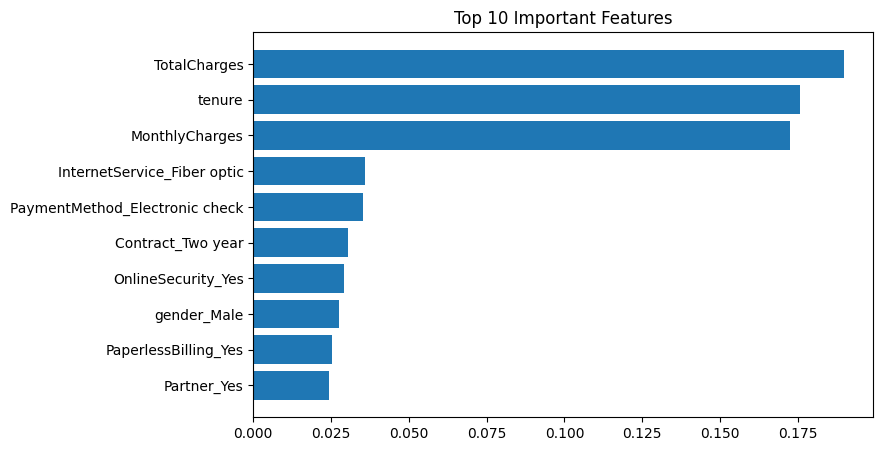

In [40]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

## PHASE 6 (Training the XG Boost model)

Training Model

In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Predictions

In [42]:
xgb_pred = xgb.predict(X_test)

Accuracy

In [43]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8133427963094393


Classification Report

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



Confusion Matrix

In [45]:
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(y_test, xgb_pred)

print(xgb_cm)

[[942  94]
 [169 204]]


Feature Importance

In [46]:
import pandas as pd

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance.head(10))

                           Feature  Importance
24               Contract_One year    0.210642
10     InternetService_Fiber optic    0.203486
25               Contract_Two year    0.171877
11              InternetService_No    0.083119
28  PaymentMethod_Electronic check    0.060990
1                           tenure    0.058888
23             StreamingMovies_Yes    0.037089
13              OnlineSecurity_Yes    0.021039
26            PaperlessBilling_Yes    0.020634
19                 TechSupport_Yes    0.018513


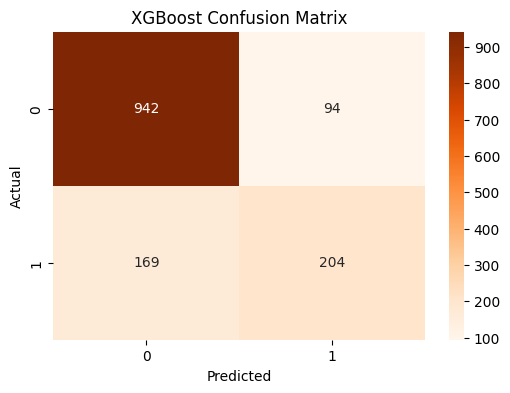

In [47]:
plt.figure(figsize=(6,4))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

XGBoost Feature Importance Plot

In [48]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

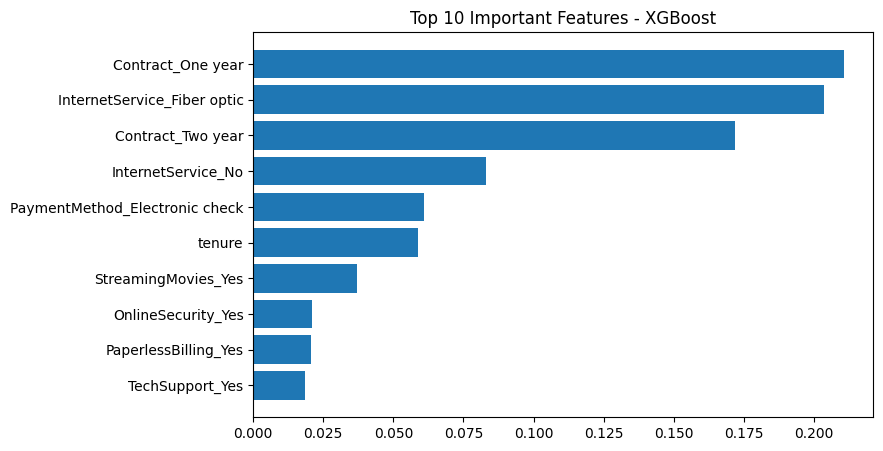

In [49]:
xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

top10_xgb = xgb_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10_xgb["Feature"],
    top10_xgb["Importance"]
)

plt.title("Top 10 Important Features - XGBoost")

plt.gca().invert_yaxis()

plt.show()

## PHASE 7 (Comparision of all three models)

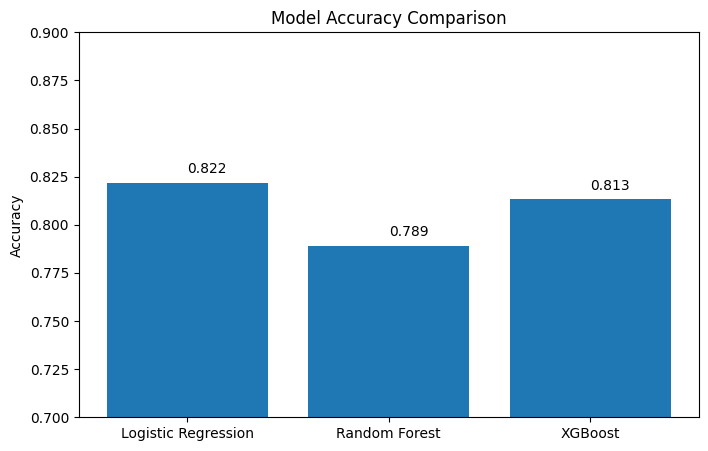

In [50]:
lr_acc = accuracy
rf_acc = rf_accuracy
xgb_acc = xgb_accuracy
models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

accuracies = [
    lr_acc,
    rf_acc,
    xgb_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0.7, 0.9)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.3f}")

plt.show()

Comparision Table

In [61]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Random Forest",
              "XGBoost"],
    "Accuracy": [lr_acc,
                 rf_acc,
                 xgb_acc]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.821859
1,Random Forest,0.789212
2,XGBoost,0.813343


## Business Impact

Accurate churn prediction enables companies to:

- Identify customers likely to leave.
- Develop targeted retention strategies.
- Improve customer satisfaction.
- Reduce revenue loss caused by customer attrition.

Machine learning models can therefore serve as a valuable decision-support tool for customer retention programs.

# Conclusion

In this project, I built a machine learning model to predict customer churn using the IBM Telco Customer Churn dataset. The main objective was to understand which factors are related to customer churn and to predict whether a customer is likely to leave the service.

I started by understanding the dataset and performing Exploratory Data Analysis (EDA). From the analysis, I observed that customers with lower tenure, month-to-month contracts, higher monthly charges, fiber optic internet service, and electronic check payment methods showed higher churn compared to other customers.

After completing the preprocessing steps, I trained multiple machine learning models including Logistic Regression, Random Forest, and XGBoost. The performance of these models was evaluated using accuracy, confusion matrix, precision, recall, and F1-score. Among the models tested, Logistic Regression gave the best overall performance with an accuracy of around 82%.

Feature importance analysis also showed that attributes such as TotalCharges, tenure, MonthlyCharges, contract type, and internet service type played an important role in predicting customer churn. This was also consistent with some of the patterns observed during EDA.

Overall, this project helped me understand the complete machine learning workflow, starting from data understanding and preprocessing to model building and evaluation. The results show that machine learning can be used to identify customers who are likely to churn, which can help companies take early actions to improve customer retention and reduce potential revenue loss.

As future work, the project can be improved by performing hyperparameter tuning, trying additional machine learning algorithms, and deploying the final model using a web application for real-time predictions.
